# Lab: Polynomial Regression

*In this lab, we will build a **Polynomial Regression** model using scikit-learn, guided by the [Foundational Methodology for Data Science](../../../05_methodology/). While real-world projects require comprehensive documentation at each stage, this lab focuses on a streamlined, practical approach to demonstrate the core concepts and workflow. Therefore we will settle with the summaries of hypothetical stage reports.*

---

## Stages 1-5
This lab notebook builds directly on the findings from the [Multiple Linear Regression Lab](./07_multiple_linear_regression_lab.ipynb), where we aimed to build a predictive model using data on TV, Radio, and Newspaper advertising to better explain sales variance and guide budget allocation. Therefore Stages 1 through 5 (Business Understanding, Analytic Approach, Data Requirements, Data Collection, and Data Understanding) are considered complete. We will proceed directly with preparing the data for our new Polynomial Regression model.

---

> ### 📝 1-5. Previous Stages Report (Summary)
> *   **Strong Initial Performance:** The Multiple Linear Regression model achieved a high R-squared of **~0.90**, explaining about 90% of the variance in sales.
> *   **Key Insight:** The model identified `TV` and `Radio` as strong, statistically significant predictors, while proving that `Newspaper` spend was statistically insignificant.
> *   **Important Flaw:** The model's **residual plot showed a noticeable U-shaped pattern**, indicating that it systematically under-predicted sales for low and high-spending markets and over-predicted for mid-range markets. This violated the linearity assumption.
> *   **Decision and Next Steps:** Due to the systematic errors revealed in the residual analysis, the decision was **"No-Go for Deployment."** The recommended next step was to use that model as a baseline model and to experiment with a new candidate model capable of capturing non-linear relationships.
>


---

## Stage 6: Data Preparation
Again, we won't need a data cleaning step, but we still need to import necessary libraries and load our data.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")
plt.rcParams["figure.figsize"] = (8, 6)

In [2]:
# Read data
sales_df = pd.read_csv("./data/advertising.csv", usecols=['TV', 'Radio', 'Newspaper', 'Sales'])
sales_df.columns = [col.lower() for col in sales_df.columns]
sales_df.head()

,tv,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


### 6.1. Final Dataset Split

This time we will define two feature matrices: one with all three features (`tv`, `radio`, and `newspaper`) and another with only the two significant features (`tv` and `radio`). We will then split both datasets into training and testing sets.

In [3]:
# Create feature matrices and target vector
X_all = sales_df[['tv', 'radio', 'newspaper']]
X_sig = sales_df[['tv', 'radio']]
y = sales_df['sales']

# Split the data into training (80%) and testing (20%) sets
X_all_train, X_all_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)
X_sig_train, X_sig_test, _, _ = train_test_split(X_sig, y, test_size=0.2, random_state=42)

Now let's create the polynomial features for the training and test sets of our feature matrices:

In [4]:
# For all features
poly_all = PolynomialFeatures(degree=2, include_bias=False)
X_all_train_poly = poly_all.fit_transform(X_all_train)
X_all_test_poly = poly_all.transform(X_all_test)

# For significant features
poly_sig = PolynomialFeatures(degree=2, include_bias=False)
X_sig_train_poly = poly_sig.fit_transform(X_sig_train)
X_sig_test_poly = poly_sig.transform(X_sig_test)


---

> ### 📝 6. Data Preparation Report (Summary)
> * **Data Loading:** The advertising dataset was successfully loaded, containing columns for `tv`, `radio`, `newspaper`, and `sales`.
> * **Feature Selection:** Two feature matrices were created: one with all three advertising channels and another with only `tv` and `radio`, based on prior significance analysis.
> * **Data Splitting:** Both datasets were split into training (80%) and testing (20%) sets, using a fixed random state for reproducibility.
> * **Polynomial Feature Generation:** Polynomial features (degree 2) were generated for both training and testing sets, enabling the model to capture non-linear relationships.

---

## Stage 7: Modeling
Let's load our baseline model, which is the Multiple Linear Regression model from the [previous lab](./07_multiple_linear_regression_lab.ipynb), and train our candidate models.

In [5]:
# Load the baseline model
mlr_model = joblib.load("./models/multiple_linear_regression_model.pkl")

# Train candidate models
poly_all_model = LinearRegression().fit(X_all_train_poly, y_train)
poly_sig_model = LinearRegression().fit(X_sig_train_poly, y_train)


---

> ### 📝 7. Modeling Report (Summary)
> * **Baseline Model:** The Multiple Linear Regression model was loaded as the baseline for comparison.
> * **Candidate Models:** Two Polynomial Regression models were trained: one with all three features and another with only `tv` and `radio`.

---

## Stage 8: Evaluation

### 8.1. Evaluation Metrics
Let's start the evaluation stage with calculating the R-squared and Root Mean Square Error (RMSE):

In [6]:
# Multiple Linear Regression Model Predictions and Evaluation Metrics
y_pred_mlr = mlr_model.predict(X_all_test)
rmse_mlr = np.sqrt(mean_squared_error(y_test, y_pred_mlr))
r2_mlr = r2_score(y_test, y_pred_mlr)

# Polynomial Regression Model (All Features) Predictions and Evaluation Metrics
y_pred_poly_all = poly_all_model.predict(X_all_test_poly)
rmse_poly_all = np.sqrt(mean_squared_error(y_test, y_pred_poly_all))
r2_poly_all = r2_score(y_test, y_pred_poly_all)

# Polynomial Regression Model (Significant Features) Predictions and Evaluation Metrics
y_pred_poly_sig = poly_sig_model.predict(X_sig_test_poly)
rmse_poly_sig = np.sqrt(mean_squared_error(y_test, y_pred_poly_sig))
r2_poly_sig = r2_score(y_test, y_pred_poly_sig)

# Print evaluation metrics
print("Multiple Linear Regression Model:")
print(f"  RMSE: {rmse_mlr:.4f}")
print(f"  R²: {r2_mlr:.4f}")
print("Polynomial Regression Model (All Features):")
print(f"  RMSE: {rmse_poly_all:.4f}")
print(f"  R²: {r2_poly_all:.4f}")
print("Polynomial Regression Model (Significant Features):")
print(f"  RMSE: {rmse_poly_sig:.4f}")
print(f"  R²: {r2_poly_sig:.4f}")

Multiple Linear Regression Model:
  RMSE: 1.7816
  R²: 0.8994
Polynomial Regression Model (All Features):
  RMSE: 0.6426
  R²: 0.9869
Polynomial Regression Model (Significant Features):
  RMSE: 0.6035
  R²: 0.9885


* 📌 The Polynomial Regression Model using only the significant features (`tv` and `radio`) outperformed both the baseline Multiple Linear Regression model and the Polynomial Regression model using all features.
* 📌 This model achieved the highest R-squared (0.9885) and the lowest RMSE (0.6035), indicating it best captures the underlying relationship in the data without overfitting.

### 8.2. Evaluation Plots
Now it's time to evaluate our models visually. Let's start with comparing the actual values to the predicted ones.

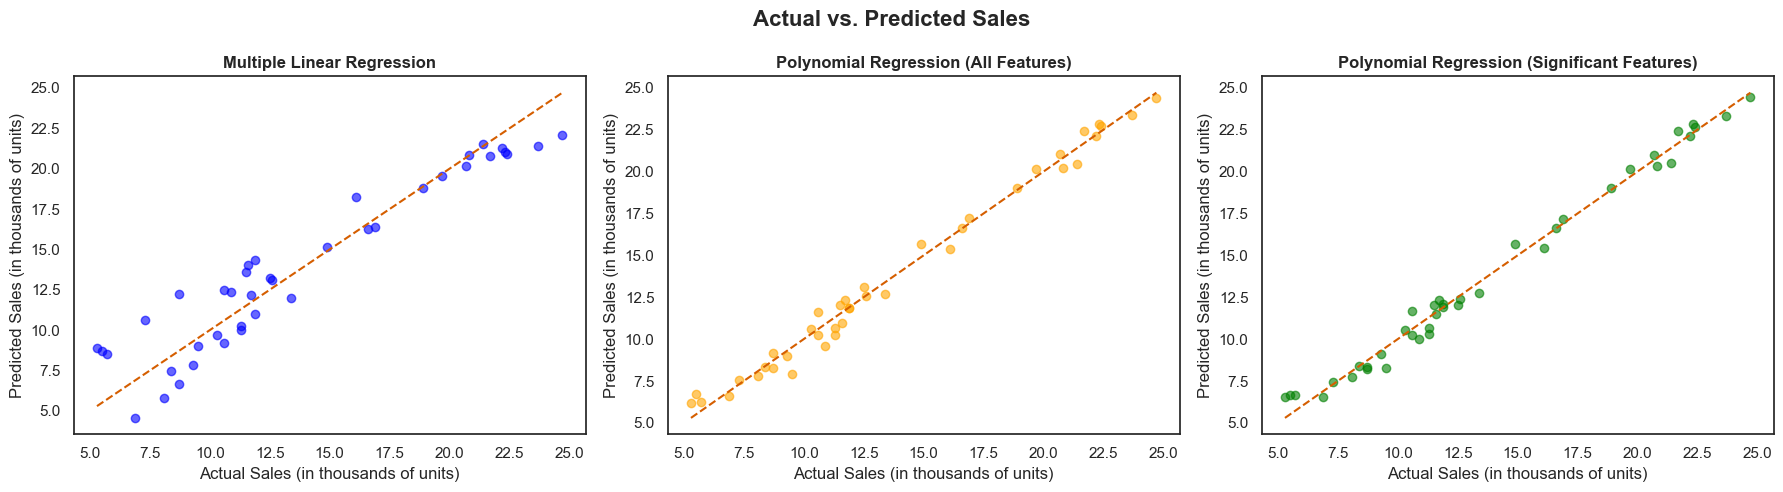

In [7]:
plt.figure(figsize=(18, 5))
plt.suptitle("Actual vs. Predicted Sales", fontsize=16, fontweight='bold')

plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred_mlr, color="blue", alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Multiple Linear Regression", fontweight="bold")
plt.xlabel("Actual Sales (in thousands of units)")
plt.ylabel("Predicted Sales (in thousands of units)")

plt.subplot(1, 3, 2)
plt.scatter(y_test, y_pred_poly_all, color="orange", alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Polynomial Regression (All Features)", fontweight="bold")
plt.xlabel("Actual Sales (in thousands of units)")
plt.ylabel("Predicted Sales (in thousands of units)")

plt.subplot(1, 3, 3)
plt.scatter(y_test, y_pred_poly_sig, color="green", alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Polynomial Regression (Significant Features)", fontweight="bold")
plt.xlabel("Actual Sales (in thousands of units)")
plt.ylabel("Predicted Sales (in thousands of units)")

plt.tight_layout()
plt.show()

* 📌 The plot above clearly indicates that the Polynomial Regression model with degree 2 and using only `tv` and `radio` as predictors provide the best fit to the data, closely aligning with the ideal diagonal line. This suggests that this model accurately captures the relationship betweeen the predictors and sales, outperforming both the Multiple Linear Regression model and the Polynomial Regression model using all features.

Now let's see whether the residuals show any patterns:

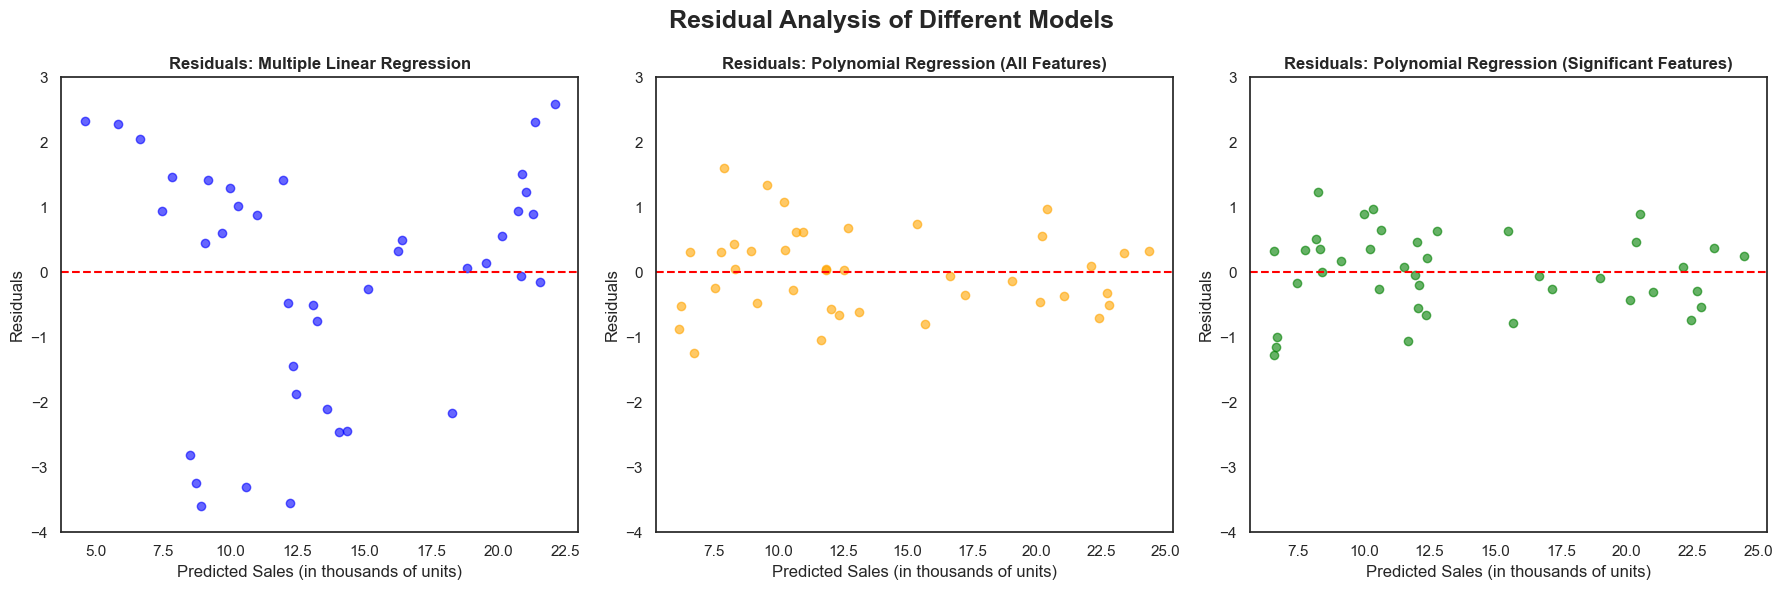

In [27]:
# Calculate the residuals
residuals_mlr = y_test - y_pred_mlr
residuals_poly_all = y_test - y_pred_poly_all
residuals_poly_sig = y_test - y_pred_poly_sig

# Create the plot
plt.figure(figsize=(18, 6))
plt.suptitle("Residual Analysis of Different Models", fontsize=18, fontweight="bold")

plt.subplot(1, 3, 1)
plt.scatter(x=y_pred_mlr, y=residuals_mlr, color="blue", alpha=0.6)
plt.axhline(0, color="red", linestyle='--')
plt.title("Residuals: Multiple Linear Regression", fontweight="bold")
plt.xlabel("Predicted Sales (in thousands of units)")
plt.ylabel("Residuals")
plt.ylim(-4,3)

plt.subplot(1, 3, 2)
plt.scatter(x=y_pred_poly_all, y=residuals_poly_all, color="orange", alpha=0.6)
plt.axhline(0, color="red", linestyle='--')
plt.title("Residuals: Polynomial Regression (All Features)", fontweight="bold")
plt.xlabel("Predicted Sales (in thousands of units)")
plt.ylabel("Residuals")
plt.ylim(-4,3)

plt.subplot(1, 3, 3)
plt.scatter(x=y_pred_poly_sig, y=residuals_poly_sig, color="green", alpha=0.6)
plt.axhline(0, color="red", linestyle='--')
plt.title("Residuals: Polynomial Regression (Significant Features)", fontweight="bold")
plt.xlabel("Predicted Sales (in thousands of units)")
plt.ylabel("Residuals")
plt.ylim(-4,3)

plt.tight_layout()
plt.show()

* 📌 The residual plot for the best performing model, Polynomial Regression (Significant Features), also shows a random scatter around zero, indicating that the model has effectively captured the non-linear relationship in the data.

Now let's walk through the Q-Q plots for the residuals of each model to assess their normality.

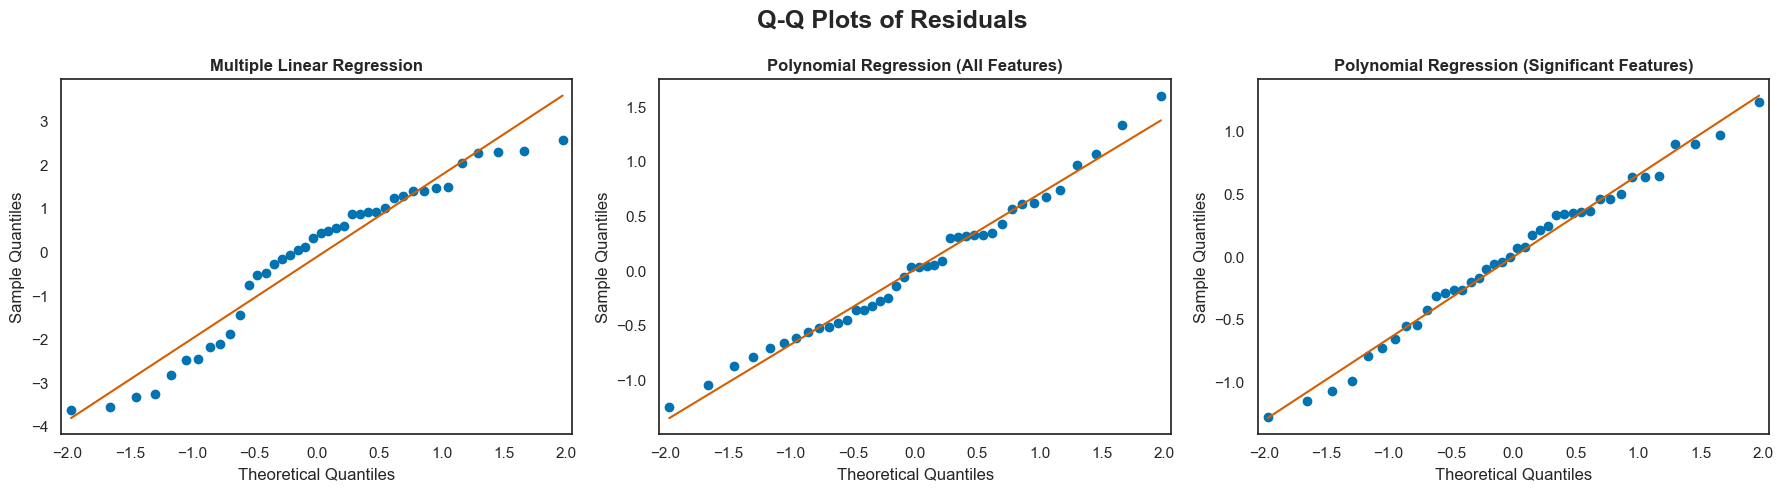

In [9]:
# Q-Q plots
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
plt.suptitle("Q-Q Plots of Residuals", fontsize=18, fontweight="bold")

sm.qqplot(residuals_mlr, line='r', ax=ax[0])
ax[0].set_title('Multiple Linear Regression', fontweight="bold")
ax[0].set_xlabel('Theoretical Quantiles')
ax[0].set_ylabel('Sample Quantiles')

sm.qqplot(residuals_poly_all, line='r', ax=ax[1])
ax[1].set_title('Polynomial Regression (All Features)', fontweight="bold")
ax[1].set_xlabel('Theoretical Quantiles')
ax[1].set_ylabel('Sample Quantiles')

sm.qqplot(residuals_poly_sig, line='r', ax=ax[2])
ax[2].set_title('Polynomial Regression (Significant Features)', fontweight="bold")
ax[2].set_xlabel('Theoretical Quantiles')
ax[2].set_ylabel('Sample Quantiles')

plt.tight_layout()
plt.show()

* 📌 The Q-Q plot for our Polynomial Regression with significant features model shows that the residuals are approximately normally distributed, with most points falling along the diagonal line. This further validates the model's assumptions and its effectiveness in capturing the underlying data patterns.

## 8.3. Business Impact Analysis

* **The Polynomial Regression Model with Significant Features (`tv`) and (`radio`)** is the clear winner. The R-squared value of **0.9885** indicated that this model explains nearly 99% of the variance in sales, a substantial improvement over the baseline Multiple Linear Regression model's R-squared of **0.8994**. Additionally, the RMSE of **0.6035** reflects a significant reduction in prediction error compared to the baseline model's RMSE of **1.7816**.
* The model shows that the synergy between TV and Radio is critical driver of sales. This provides a data-driven mandate to the marketing team: **focus budget on a coordinated TV and Radio strategy, and deprioritize Newspaper spend.**
* While our new model is exceptionally accurate, this power comes with a tradeoff: We have lost the simple, direct interpretability of the linear model, where we could say "a $1.000 increase in TV spend leads to a 45-unit increase in sales." This is because the coefficients in our polynomial model no longer have a standalone meaning. The effect of TV spend now depends on *how much* is already being spent on TV and *how much* is being spent on Radio. However, this is not a step forward. This is a step forward toward a more realistic and nuanced understanding of the market. We have moved from a simple, but flawed, "rule of thumb" to a powerful **"what-if" simulation engine.**.
* To translate this new power into actionable insights, we must shift our interpretation method from reading coefficients to visualizing the model's behaviour. Let's use visualization to answer the following two critical questions:
    1. **Diminishing Returns:** Is there a point where increasing ad spend stops being effective?
    2. **Synergy Effects:** How does spending on Radio amplify the impact of our TV budget?

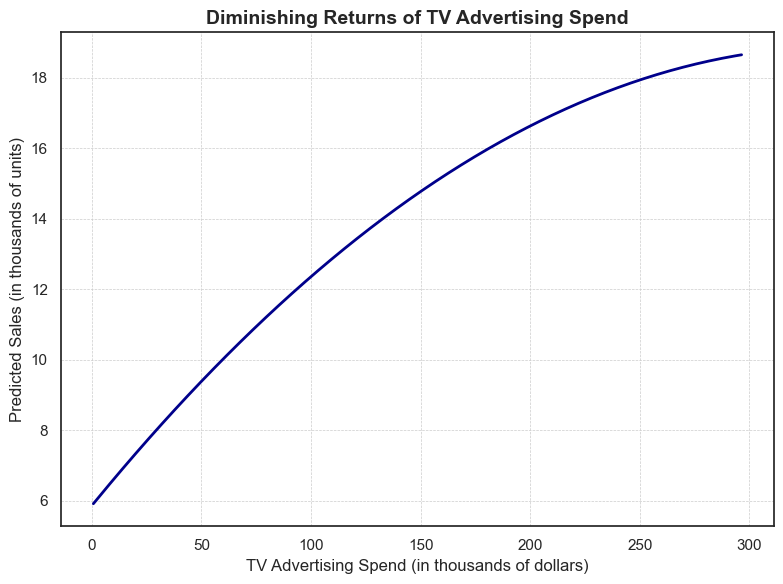

In [20]:
# --- Visualizing Diminishing Returns of TV Advertising Spend --- #

# Let's hold 'radio' constant at its median value and vary 'tv' spend to see its effect on predicted sales.
radio_median = X_sig['radio'].median()
tv_spend = np.linspace(X_sig['tv'].min(), X_sig['tv'].max(), 200)

# Create a DataFrame for predictions
tv_radio_df = pd.DataFrame({
    'tv': tv_spend,
    'radio': radio_median
})

# Transform the features using the polynomial transformer
tv_radio_poly = poly_sig.transform(tv_radio_df)

# Use the final model to predict sales
predicted_sales = poly_sig_model.predict(tv_radio_poly)   

# Create the plot
plt.figure()
plt.plot(tv_spend, predicted_sales, color="darkblue", linewidth=2)
plt.title("Diminishing Returns of TV Advertising Spend", fontweight="bold", fontsize=14)
plt.xlabel("TV Advertising Spend (in thousands of dollars)")
plt.ylabel("Predicted Sales (in thousands of units)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

The plot clerly shows a cuved relationship, confirming the principle of diminishing returns:

* At lower levels of spending (e.g., 0k to 125k dollars): The sales curve is very steep. Each additional dollar spent on TV advertising yields a significant intrease in sales.
* At higher levels of spending (e.g., above 200k dollars): The curve begins to flatten. While spending more still increases sales, the benefit of each additional dollar is much smaller.

**Business Implication:** There is a point of decreasing efficiency. This model allows the marketing team to find the "sweet spot" where their TV budget is most effective, rather than just spending as much as possible.

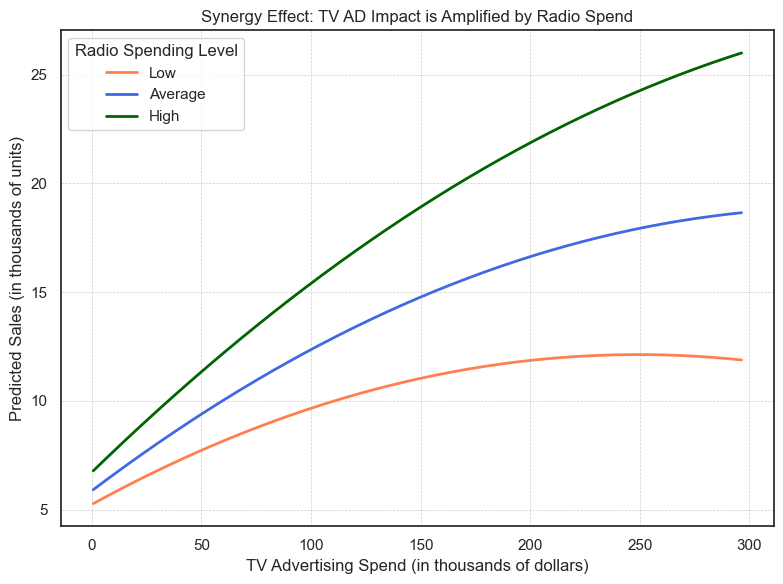

In [26]:
# --- Visualizing the Synergy Effect of TV and Radio ---

# Define low and high levels for Radio Advertising Spend
radio_low = X_sig['radio'].quantile(0.10)   # 10th percentile
radio_high = X_sig['radio'].quantile(0.90)  # 90th percentile

levels = {'Low': radio_low, 'Average': radio_median, 'High': radio_high}
colors = {'Low': 'coral', 'Average': 'royalblue', 'High': 'darkgreen'}

# Create the plot
plt.figure()
for level_name, radio_value in levels.items():
    # Create scenario DataFrame
    df = pd.DataFrame({
        'tv': tv_spend,
        'radio': radio_value,     
    })
    
    # Transform features and predict sales
    df_poly = poly_sig.transform(df)
    predicted_sales = poly_sig_model.predict(df_poly)
    
    # Plot the results
    plt.plot(tv_spend, predicted_sales, label=level_name, color=colors[level_name], linewidth=2)
    
plt.title("Synergy Effect: TV Ad Impact is Amplified by Radio Spend")
plt.xlabel("TV Advertising Spend (in thousands of dollars)")
plt.ylabel("Predicted Sales (in thousands of units)")
plt.legend(title="Radio Spending Level", loc="upper left")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

This plot powerfully illustrates the synergy (or interaction effect) between TV and Radio advertising:
* The lines are not parallel. The impact of TV spend (the slope of the line) is dramatically different at different levels of Radio spend. When Radio spend is high (the green line), the curve for TV is much steeper, meaning every dollar spent on TV is significantly more effective. This proves that **high Radio spend amplifies TV spend**. When Radio spend is low (the orange line), the TV spending curve is much flatter. This indicated that **even a large TV budget has a limited impact on its own.**

**Business Implication:** The key to maximizing marketing ROI is not to invest in TV or Radio, but to invest them together. A coordinated campaign where TV builds brand awareness and Radio acts as a high-frequency reminder is far more effective than either channel in isolation. This model gives the business a tool to quantify this synergy and optimize their cross-channel budget allocation.

---

> ### 📝 8. Evaluation Report (Summary)
> * **Model Performance:** The Polynomial Regression model using only `tv` and `radio` outperformed both the baseline Multiple Linear Regression model and the Polynomial Regression model using all features, achieving an R-squared of **0.9885** and an RMSE of **0.6035**.
> * **Visual Evaluation:** The actual vs. predicted plot showed that the Polynomial Regression model with significant features closely aligned with the ideal diagonal line, indicating accurate predictions. The residual plot displayed a random scatter around zero, confirming that the model effectively captured the non-linear relationship in the data. The Q-Q plot indicated that the residuals were approximately normally distributed.
> * **Business Impact:** The model revealed critical insights into advertising effectiveness, highlighting the importance of a coordinated TV and Radio strategy while deprioritizing Newspaper spend. The analysis of diminishing returns and synergy effects provided actionable guidance for optimizing marketing budgets.
> * **Deployment Decision:** Given the superior performance and valuable insights provided by the Polynomial Regression model with significant features, the decision is a **"Go for Deployment."** The model is ready to be implemented to guide marketing budget allocation and strategy.

---

**Next:** [Logistic Regression Theory](./11_logistic_regression_theory.md)